<a href="https://colab.research.google.com/github/jiafenggang/Algo_F/blob/master/synthmorph_shapes_3d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This demo shows how to register 3D images with an anatomy-agnostic SynthMorph
# model trained without real images. Further information: https://synthmorph.io.
#
# If you find the demo useful, please cite:
#
#     SynthMorph: learning contrast-invariant registration without acquired images
#     Hoffmann M, Billot B, Greve DN, Iglesias JE, Fischl B, Dalca AV
#     IEEE Transactions on Medical Imaging (TMI), 41 (3), 543-558, 2022
#     https://doi.org/10.1109/TMI.2021.3116879
#     https://arxiv.org/abs/2004.10282
#
#     Learning MRI contrast-agnostic registration
#     Hoffmann M, Billot B, Iglesias JE, Fischl B, Dalca AV
#     IEEE International Symposium on Biomedical Imaging (ISBI), 899-903, 2021
#     https://doi.org/10.1109/ISBI48211.2021.9434113
#     https://synthmorph.io/#papers (PDF)
#
# We distribute this notebook under the MIT License:
# https://choosealicense.com/licenses/mit

In [ ]:
# Packages from GitHub.
!pip -q install https://github.com/adalca/neurite/archive/17aa080540b61e72ed1f5f37378df41c8278dc3e.zip
!pip -q install https://github.com/freesurfer/surfa/archive/8de6c4584eee9283c50f2d7e215eaf8ff1469770.zip
!pip -q install https://github.com/voxelmorph/voxelmorph/archive/cc84aa7fe255bac6f3bad6f124106e61ea9312cf.zip

     - 133.8 kB 3.2 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     - 131.4 kB 3.7 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     | 63.9 MB 60.5 MB/s 0:00:03
  Preparing metadata (setup.py) ... done


In [ ]:
import numpy as np
import surfa as sf
import tensorflow as tf
import voxelmorph as vxm
import matplotlib.pyplot as plt

In [ ]:
# Downloads. We use unprocessed T1-weighted MRI data from subject Afterthought
# in Mindboggle-101 (https://mindboggle.info) and T2-weighted MRI from subject
# fsm27uz in FSM (https://surfer.nmr.mgh.harvard.edu/fswiki/FsmData).
%%sh
curl -C- -O https://surfer.nmr.mgh.harvard.edu/docs/synthmorph/images/t1.nii.gz
curl -C- -O https://surfer.nmr.mgh.harvard.edu/docs/synthmorph/images/t2.nii.gz
curl -C- -O https://surfer.nmr.mgh.harvard.edu/ftp/data/voxelmorph/synthmorph/shapes-dice-vel-3-res-8-16-32-256f.h5

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 9728k  100 9728k    0     0  2063k      0  0:00:04  0:00:04 --:--:-- 2225k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 12.4M  100 12.4M    0     0  2117k      0  0:00:06  0:00:06 --:--:-- 2211k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 81.2M  100 81.2M    0     0  2225k      0  0:00:37  0:00:37 --:--:-- 2245k


In [ ]:
# Helper functions. The shape has to be divisible by 16.
shape = (128, 128, 128)

def normalize(x):
  x = np.float32(x)
  x -= x.min()
  x /= x.max()
  return x[None, ..., None]


def show(x, title=None):
  x = np.squeeze(x)
  fig, axes = plt.subplots(1, 3, figsize=(12, 4))
  i, j, k = (f // 2 for f in x.shape)

  slices = x[:, j, :], x[:, :, k], x[i, :, :].T
  for x, ax in zip(slices, axes):
    ax.imshow(x, cmap='gray')
    ax.set_axis_off()

  if title:
    axes[1].text(0.50, 1.05, title, ha='center', transform=axes[1].transAxes, size=14)

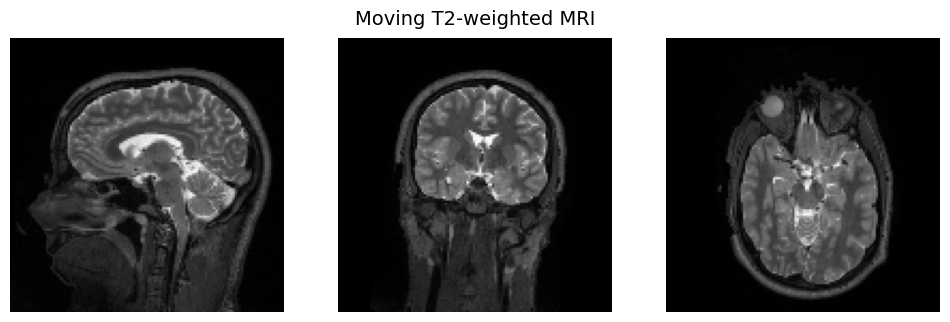

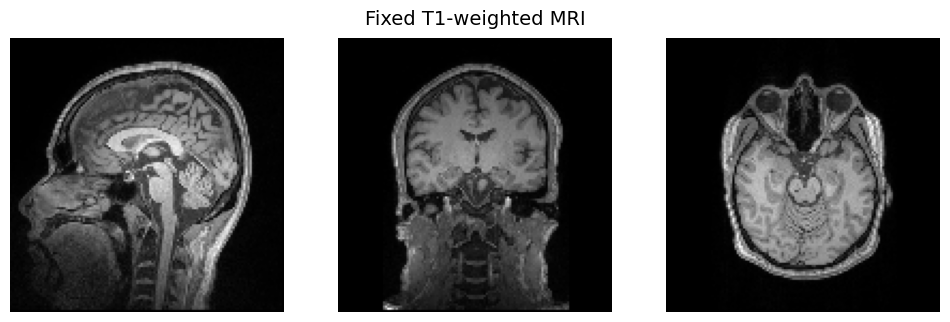

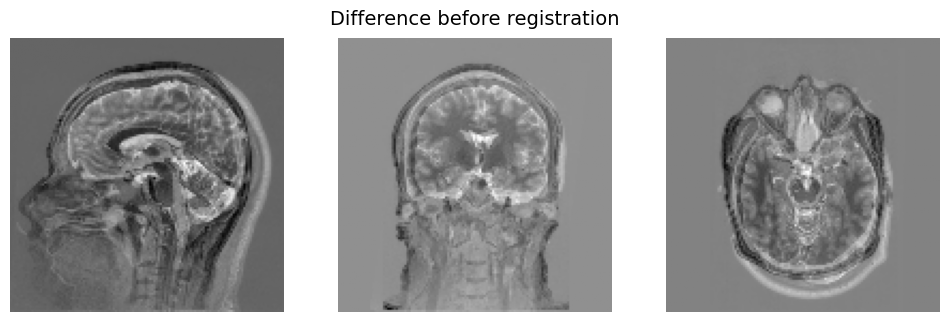

In [ ]:
# Difference before registration.
t1 = sf.load_volume('t1.nii.gz').resize(voxsize=2).reshape(shape).reorient('ILP')
t2 = sf.load_volume('t2.nii.gz').resample_like(t1)
before = normalize(t2) - normalize(t1)

show(t2, title='Moving T2-weighted MRI')
show(t1, title='Fixed T1-weighted MRI')
show(before, title='Difference before registration')

In [ ]:
# Shapes model. Assumes affine initialization and may require fine-tuning.
model = vxm.networks.VxmDense(
  nb_unet_features=([256] * 4, [256] * 6),
  int_steps=5,
  int_resolution=2,
  svf_resolution=2,
  inshape=shape,
)
model = tf.keras.Model(model.inputs, model.references.pos_flow)
model.load_weights('shapes-dice-vel-3-res-8-16-32-256f.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 93s 93s/step


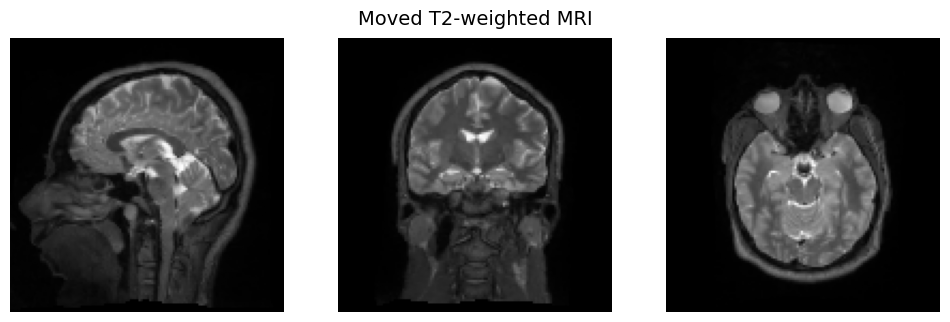

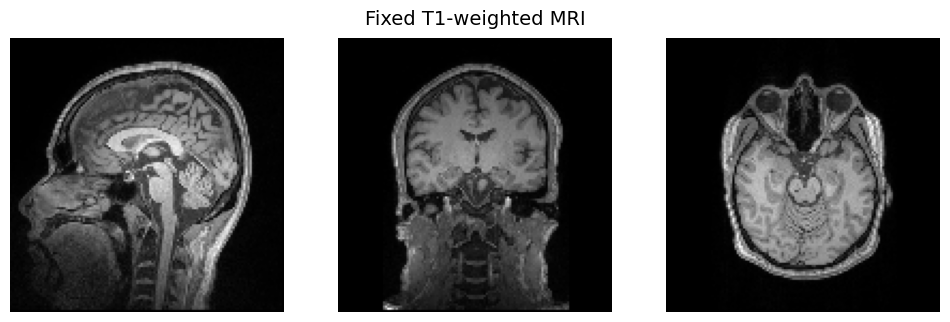

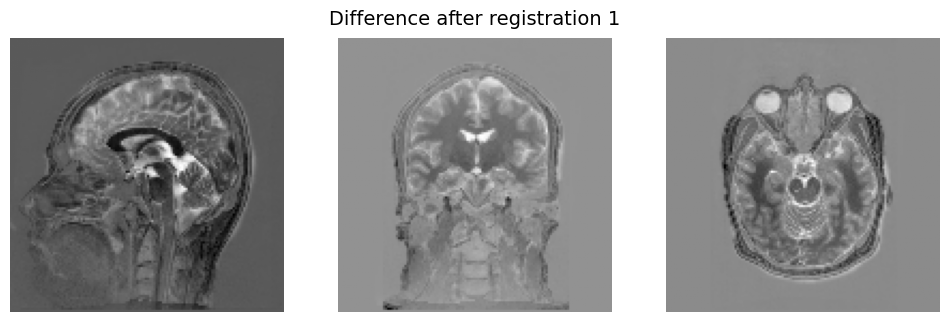

In [ ]:
# Registration 1.
moving = normalize(t2)
fixed = normalize(t1)
trans = model.predict((moving, fixed))

moved = vxm.layers.SpatialTransformer(fill_value=0)((moving, trans))
show(moved, title='Moved T2-weighted MRI')
show(fixed, title='Fixed T1-weighted MRI')
show(moved - fixed, title='Difference after registration 1')

1/1 ━━━━━━━━━━━━━━━━━━━━ 89s 89s/step


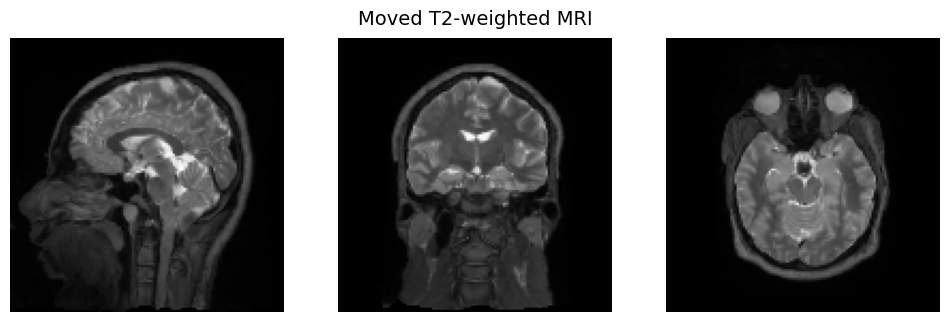

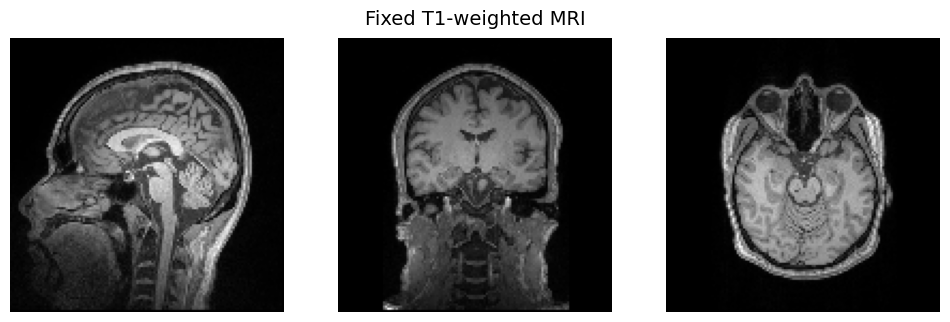

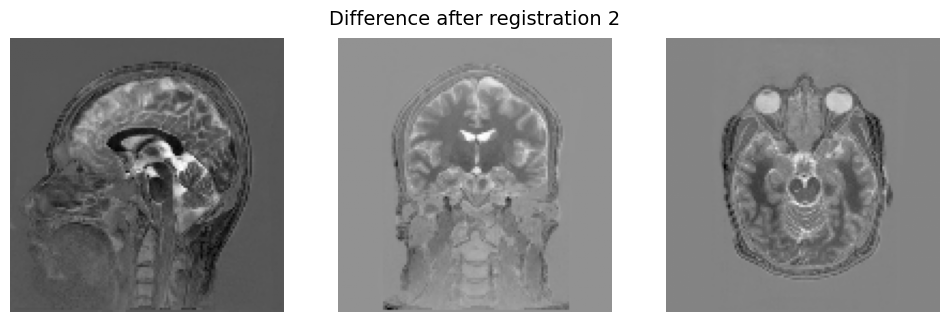

In [ ]:
# Registration 2.
resid = model.predict((moved, fixed))
trans = vxm.layers.ComposeTransform()((trans, resid))

moved = vxm.layers.SpatialTransformer(fill_value=0)((moving, trans))
show(moved, title='Moved T2-weighted MRI')
show(fixed, title='Fixed T1-weighted MRI')
show(moved - fixed, title='Difference after registration 2')

In [ ]:
# Save results.
t1.new(moved[0]).save('moved.nii.gz')
sf.Warp(trans[0], source=t2, target=t1, format=sf.Warp.Format.disp_crs).save('warp.nii.gz')

In [ ]:
# Package versions.
!pip freeze

absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.10.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.12.15
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
altair==5.5.0
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.10.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.7.2
arviz==0.22.0
astropy==7.1.0
astropy-iers-data==0.2025.8.18.0.40.14
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
Authlib==1.6.1
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.21.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.15.0
bigquery-magics==0.10.2
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.0.0
blosc2==3.7.1
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.1
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.8.3
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.3
chex==0.1.90
clarabel==0.11.1
click==8.2.1
cl